In [ ]:
# Employee will leave or stay

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# upload and read a dataset 

data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

data.fillna(method = 'ffill', inplace = True)

print(data.head())
print(data.info())

# convert  the text into numicerical

label_encoder = {}
for column in data.select_dtypes(include = ['object']).columns:
    le = LabelEncoder()
    data[column]=le.fit_transform(data[column])
    label_encoder[column] = le

# input feature and target varible

x = data[["JobSatisfaction", "MonthlyIncome", "YearsAtCompany", "WorkLifeBalance"]]
y = data["Attrition"]

# training and testing the data

x_train, x_test, y_train , y_test = train_test_split(x , y, test_size =0.2, random_state = 42)

# random forest

model = RandomForestClassifier(n_estimators = 200, max_depth = 4, random_state = 42)
model.fit(x_train, y_train)
pred  = model.predict(x_test)

# Elevaltion

print("predication: leave->1, stay->0:", pred)
print("accuracy_score:", accuracy_score(y_test, pred))
print("confusion_matrix:\n", confusion_matrix(y_test, pred))
print("classification_report:\n", classification_report(y_test, pred))

#Feature importance
importances = model.feature_importances_
feature_names = x.columns
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
print(feat_imp.sort_values(by="Importance", ascending=False).head(10))


C:\Users\SIDDHU\AppData\Local\Temp\ipykernel_23036\4248143371.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method = 'ffill', inplace = True)


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [ ]:
# Detect True new or Fake New

Accuracy: 0.9987750556792873

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



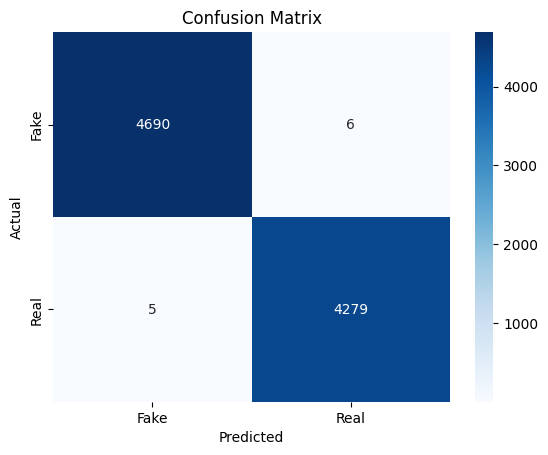

In [1]:
# Fake News Detection using Random Forest
# Dataset: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# -----------------------------
# 1. Load Dataset
# -----------------------------
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Add labels
fake['label'] = 0   # Fake
true['label'] = 1   # Real

# Combine datasets
df = pd.concat([fake, true], axis=0).reset_index(drop=True)

# -----------------------------
# 2. Feature Engineering
# -----------------------------
# Title length
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

# Source credibility score (dummy example: based on publisher name if available)
# If 'subject' column exists, we can assign credibility scores
if 'subject' in df.columns:
    credibility_map = {
        'politics': 0.8,
        'world': 0.9,
        'government': 0.85,
        'middle-east': 0.7,
        'US_News': 0.95,
        'News': 0.9,
        'other': 0.5
    }
    df['credibility_score'] = df['subject'].map(lambda x: credibility_map.get(x, 0.6))
else:
    # If no subject column, assign neutral credibility
    df['credibility_score'] = 0.5

# -----------------------------
# 3. Text Preprocessing (TF-IDF)
# -----------------------------
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_text = tfidf.fit_transform(df['text'])

# Combine text features with numeric features
X = np.hstack((X_text.toarray(),
               df[['title_length', 'credibility_score']].values))

y = df['label']

# -----------------------------
# 4. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 5. Train Random Forest
# -----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# -----------------------------
# 6. Evaluation
# -----------------------------
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Alchol quality-check

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# load dataset

red_wine = pd.read_csv("winequality-red.csv", sep =';')
white_wine = pd.read_csv("winequality-white.csv", sep = ';')

#joint two dataset

df  = pd.concat([red_wine , white_wine],axis = 0)

print("Dataset shape:",df.shape)
print(df['quality'].value_counts())

# convert quality into class

def quality_to_label(q):
    if q <= 4:
        return "poor"
    elif q <= 6:
        return "Average"
    else:
        return "Good"

df['quality_label'] = df['quality'].apply( quality_to_label)
print(df['quality_label'].value_counts())

#input and target varible

x = df.drop(columns = ['quality', 'quality_label'])
y = df['quality_label']

# standard scaler

scaler  = StandardScaler()

x_scaler = scaler.fit_transform(x)

# train_test _split

x_train, x_test, y_train, y_test = train_test_split(x_scaler, y, test_size = 0.3, random_state = 42)

# model 

model = RandomForestClassifier(n_estimators = 200, max_depth  = 4, random_state = 42)
model.fit(x_train, y_train)
pred = model.predict(x_test)

# elevaction

print("prediction:",pred)
print("accuracy_score:", accuracy_score(y_test, pred))
print("confusion_matrix:", confusion_matrix(y_test, pred))
print("classification_report:", classification_report(y_test, pred))


Dataset shape: (6497, 12)
quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
quality_label
Average    4974
Good       1277
poor        246
Name: count, dtype: int64
prediction: ['Average' 'Average' 'Average' ... 'Good' 'Average' 'Average']
accuracy_score: 0.7933333333333333
confusion_matrix: [[1474   33    0]
 [ 292   73    0]
 [  78    0    0]]
classification_report:               precision    recall  f1-score   support

     Average       0.80      0.98      0.88      1507
        Good       0.69      0.20      0.31       365
        poor       0.00      0.00      0.00        78

    accuracy                           0.79      1950
   macro avg       0.50      0.39      0.40      1950
weighted avg       0.75      0.79      0.74      1950



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
